## 1. Feature Engineering Avancé 

In [1]:
import pandas as pd
import numpy as np

# On recharge les données propres
X = pd.read_csv('public/X_features.csv')
y = pd.read_csv('public/y_target.csv').values.ravel()

def add_smart_features(df):
    df_new = df.copy()
    
    # 1. Ratio Salaire / Age : Est-on bien payé pour son âge ?
    # On ajoute +1 pour éviter la division par zéro (sécurité dev)
    df_new['ratio_salaire_age'] = df_new['revenu_mensuel'] / df_new['age']
    
    # 2. Stagnation : Années au même poste / Années dans la boite
    # Si proche de 1, la personne n'a jamais bougé -> risque
    df_new['taux_stagnation'] = df_new['annees_dans_le_poste_actuel'] / (df_new['annees_dans_l_entreprise'] + 1)
    
    # 3. Rentabilité Expérience : Salaire / Total années exp
    df_new['salaire_par_annee_exp'] = df_new['revenu_mensuel'] / (df_new['annee_experience_totale'] + 1)
    
    return df_new

# Application
X_enriched = add_smart_features(X)
print(f"Features ajoutées. Nouvelles dimensions : {X_enriched.shape}")

Features ajoutées. Nouvelles dimensions : (1470, 43)


## 2. Configuration du modèle

In [2]:
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score

# 1. Split Stratifié (On garde la même proportion de départs dans Train/Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_enriched, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Définition du Modèle "Corrigé"
rf_balanced = RandomForestClassifier(
    n_estimators=200,          # Plus d'arbres pour stabiliser
    max_depth=10,              # Limite la profondeur (Anti-Overfitting)
    min_samples_leaf=4,        # Impose un minimum de données par feuille (Lissage)
    class_weight='balanced',   # Gestion du déséquilibre (Pondération automatique)
    random_state=42,
    n_jobs=-1                  # Utilise tous les cœurs CPU
)

## 3. Validation Croisée 

In [3]:
# Définition des métriques à surveiller
scoring = {
    'recall': 'recall',       # Priorité métier : ne pas rater les départs
    'precision': 'precision', # Éviter les fausses alertes
    'f1': 'f1',               # L'équilibre
    'roc_auc': 'roc_auc'      # Capacité globale de classement
}

# Cross-Validation (5 Folds)
cv_results = cross_validate(rf_balanced, X_train, y_train, cv=5, scoring=scoring)

# Affichage "Dev Style"
print("--- Résultats Validation Croisée (Moyenne +/- Std) ---")
for metric in scoring.keys():
    mean_score = cv_results[f'test_{metric}'].mean()
    std_score = cv_results[f'test_{metric}'].std()
    print(f"{metric.capitalize():<10} : {mean_score:.4f} (+/- {std_score:.4f})")

--- Résultats Validation Croisée (Moyenne +/- Std) ---
Recall     : 0.3211 (+/- 0.0562)
Precision  : 0.6002 (+/- 0.0841)
F1         : 0.4167 (+/- 0.0623)
Roc_auc    : 0.7848 (+/- 0.0551)


## 4. Tests de différents seuils


==================== RAPPORT POUR SEUIL 0.2 ====================
              precision    recall  f1-score   support

           0       0.97      0.46      0.62       247
           1       0.24      0.91      0.38        47

    accuracy                           0.53       294
   macro avg       0.60      0.69      0.50       294
weighted avg       0.85      0.53      0.58       294


==================== RAPPORT POUR SEUIL 0.35 ====================
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       247
           1       0.41      0.62      0.49        47

    accuracy                           0.80       294
   macro avg       0.66      0.72      0.68       294
weighted avg       0.84      0.80      0.81       294


==================== RAPPORT POUR SEUIL 0.8 ====================
              precision    recall  f1-score   support

           0       0.85      1.00      0.91       247
           1       0.67      0.04     

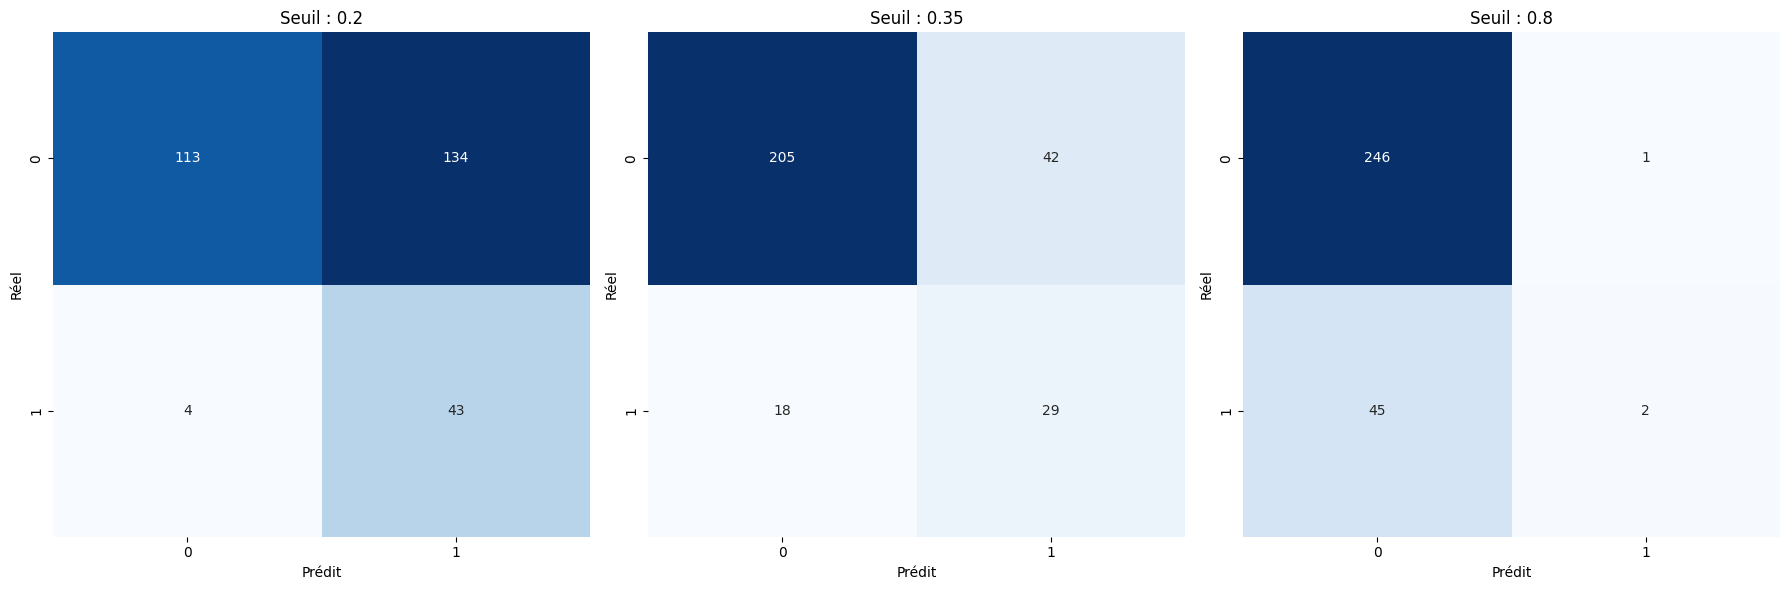

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. On entraîne le modèle une bonne fois pour toutes sur le Train
rf_balanced.fit(X_train, y_train)

# 2. On récupère les PROBABILITÉS (les scores bruts) sur le Test
# On ne veut pas la prédiction (0 ou 1), mais le % de risque
y_probs = rf_balanced.predict_proba(X_test)[:, 1]

# 3. Tes 3 seuils à tester
seuils = [0.2, 0.35, 0.8]

plt.figure(figsize=(18, 6))

for i, seuil in enumerate(seuils):
    # On applique le seuil manuel : Si Proba > Seuil alors 1, sinon 0
    y_pred_seuil = (y_probs >= seuil).astype(int)
    
    # Affichage
    print(f"\n{'='*20} RAPPORT POUR SEUIL {seuil} {'='*20}")
    print(classification_report(y_test, y_pred_seuil))
    
    # Matrice
    plt.subplot(1, 3, i+1)
    sns.heatmap(confusion_matrix(y_test, y_pred_seuil), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Seuil : {seuil}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")

plt.tight_layout()
plt.show()

## 5. Test final

--- RÉSULTATS FINAUX (Seuil optimisé à 0.35) ---
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       247
           1       0.41      0.62      0.49        47

    accuracy                           0.80       294
   macro avg       0.66      0.72      0.68       294
weighted avg       0.84      0.80      0.81       294



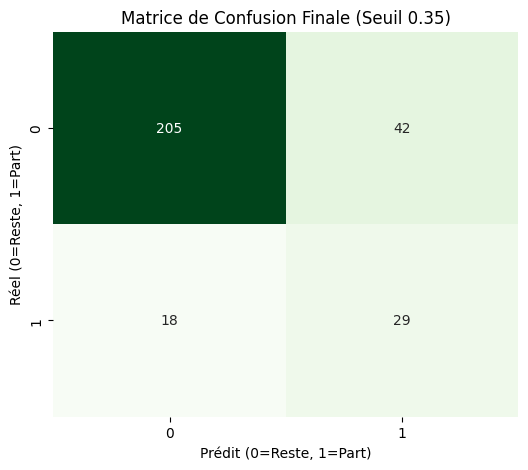

Sur les 47 départs réels, le modèle en a détecté 29 (Recall: 61.70%).
Il a généré 42 fausses alertes pour attraper ces profils.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Configuration du seuil retenu
FINAL_THRESHOLD = 0.35

# 2. Application du seuil sur les probabilités calculées précédemment
y_pred_final = (y_probs >= FINAL_THRESHOLD).astype(int)

# 3. Affichage des résultats définitifs
print(f"--- RÉSULTATS FINAUX (Seuil optimisé à {FINAL_THRESHOLD}) ---")
print(classification_report(y_test, y_pred_final))

# 4. Matrice de Confusion Finale
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title(f"Matrice de Confusion Finale (Seuil {FINAL_THRESHOLD})")
plt.xlabel("Prédit (0=Reste, 1=Part)")
plt.ylabel("Réel (0=Reste, 1=Part)")
plt.show()

# Interprétation automatique pour ton rapport
tn, fp, fn, tp = cm.ravel()
print(f"Sur les {tp+fn} départs réels, le modèle en a détecté {tp} (Recall: {tp/(tp+fn):.2%}).")
print(f"Il a généré {fp} fausses alertes pour attraper ces profils.")

# étape 5

## 1. Fine-Tuning

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve
import numpy as np

# 1. Définition de la grille "V2" (Plus robuste)
# On ajoute max_features pour diversifier les arbres et on teste autour de leaf=6
param_grid = {
    'n_estimators': [200, 300, 500],    # Plus d'arbres pour stabiliser
    'max_depth': [10, 15, 20, None],    # Profondeur
    'min_samples_leaf': [3, 5, 8],      # On encadre la valeur 6 trouvée avant
    'class_weight': ['balanced', 'balanced_subsample'],
    'max_features': ['sqrt', 0.5]       # NOUVEAU : Teste des arbres plus larges
}

# 2. Initialisation du modèle
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Lancement du GridSearch
print("Lancement du GridSearch V2 (Cela peut prendre 1 à 2 minutes)...")
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,              # 3 folds pour garder un temps de calcul raisonnable
    scoring='f1',      # On cherche toujours le meilleur compromis
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 4. Récupération du meilleur modèle
best_rf = grid_search.best_estimator_
print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score F1 (CV) : {grid_search.best_score_:.4f}")

print("-" * 50)
print("--- OPTIMISATION DU SEUIL & VÉRIFICATION ---")

# Calcul des probabilités sur le Test Set
y_probs_best = best_rf.predict_proba(X_test)[:, 1]

# Recherche automatique du NOUVEAU seuil optimal pour ce modèle précis
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_best)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_idx = np.argmax(f1_scores)
new_threshold = thresholds[best_idx]

print(f"Nouveau seuil optimal calculé : {new_threshold:.4f}")

# Application du nouveau seuil
y_pred_best = (y_probs_best >= new_threshold).astype(int)

print("\nClassification Report (Jeu de Test avec nouveau seuil) :")
print(classification_report(y_test, y_pred_best))

Lancement du GridSearch V2 (Cela peut prendre 1 à 2 minutes)...
Fitting 3 folds for each of 144 candidates, totalling 432 fits

Meilleurs paramètres : {'class_weight': 'balanced_subsample', 'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 8, 'n_estimators': 500}
Meilleur score F1 (CV) : 0.4869
--------------------------------------------------
--- OPTIMISATION DU SEUIL & VÉRIFICATION ---
Nouveau seuil optimal calculé : 0.3833

Classification Report (Jeu de Test avec nouveau seuil) :
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       247
           1       0.45      0.66      0.53        47

    accuracy                           0.82       294
   macro avg       0.69      0.75      0.71       294
weighted avg       0.85      0.82      0.83       294



## 2. Feature Importance Globale

1. Affichage de l'importance native...


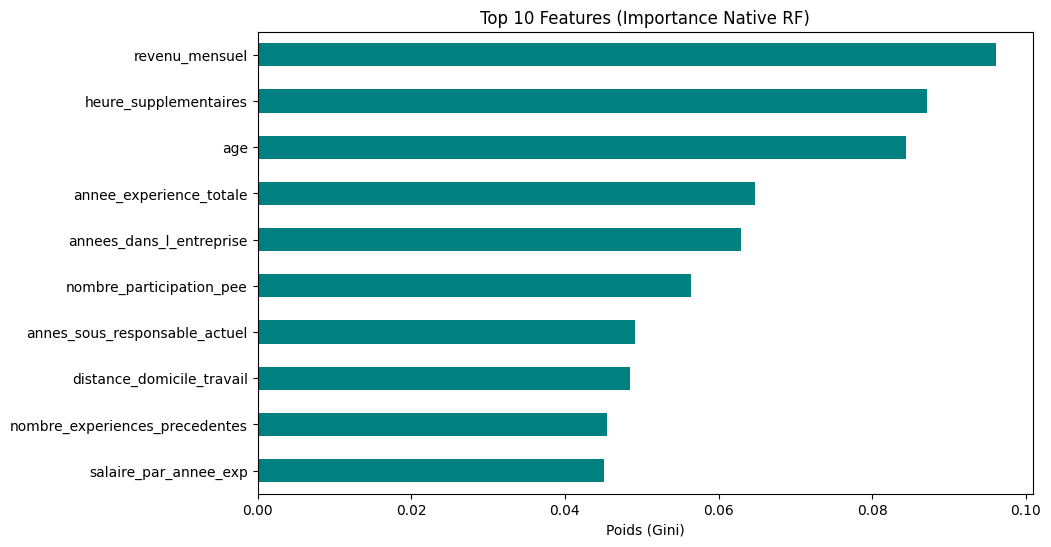

2. Calcul de la Permutation Importance (Patience...)...


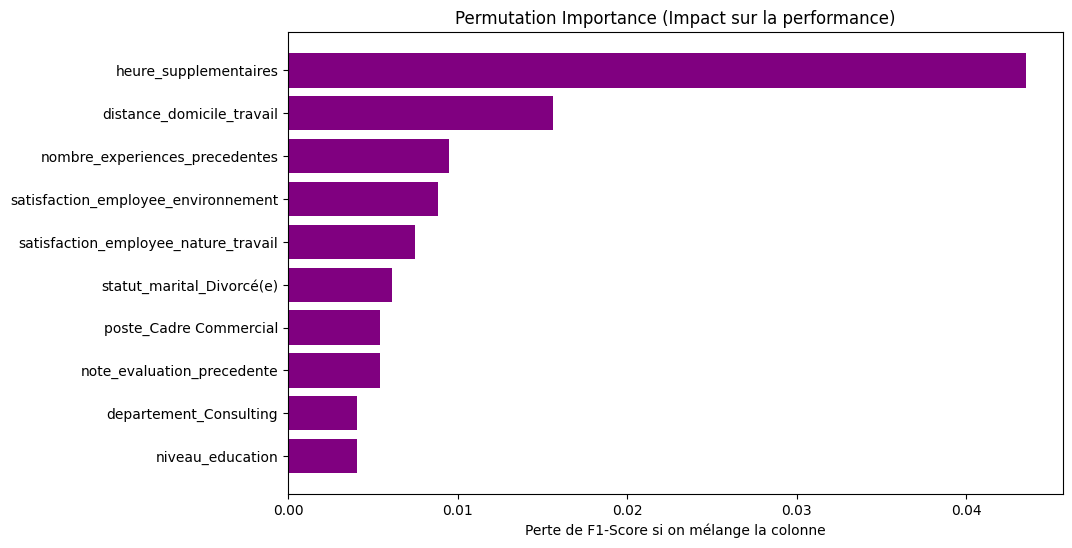

3. Calcul des valeurs SHAP...
Génération du graphique Beeswarm...


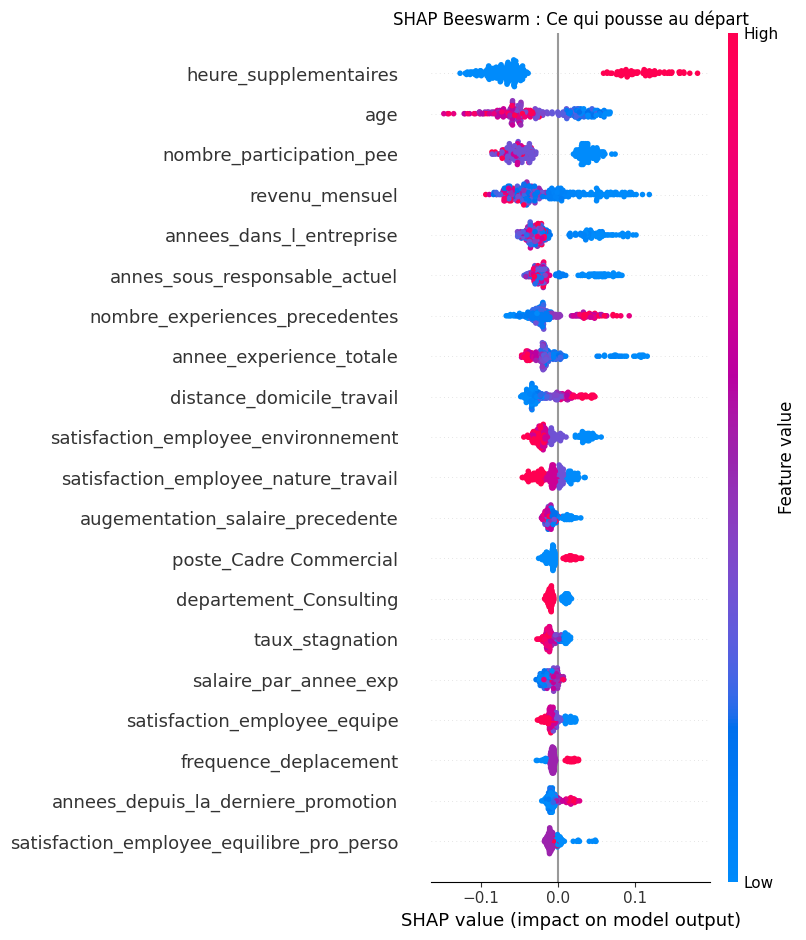

4. Zoom (Scatter Plot) sur la variable n°1 : heure_supplementaires


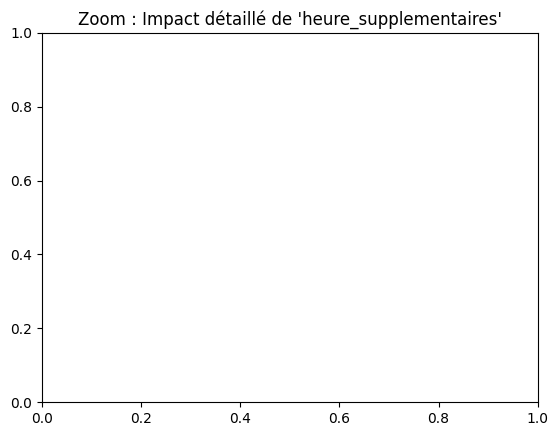

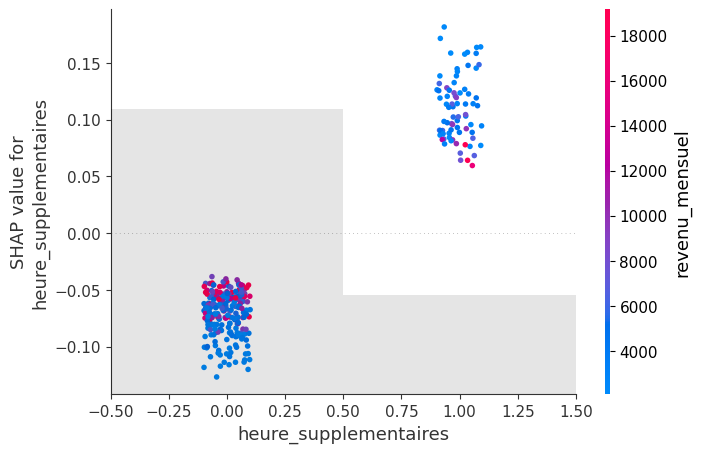

In [11]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# ==============================================================================
# 1. Importance Native (Gini Importance)
# ==============================================================================
print("1. Affichage de l'importance native...")
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 Features (Importance Native RF)")
plt.xlabel("Poids (Gini)")
plt.show()

# ==============================================================================
# 2. Permutation Importance (Test de robustesse)
# ==============================================================================
print("2. Calcul de la Permutation Importance (Patience...)...")
perm_importance = permutation_importance(best_rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx][-10:], perm_importance.importances_mean[sorted_idx][-10:], color='purple')
plt.title("Permutation Importance (Impact sur la performance)")
plt.xlabel("Perte de F1-Score si on mélange la colonne")
plt.show()

# ==============================================================================
# 3. SHAP Summary Plot (Beeswarm)
# ==============================================================================
print("3. Calcul des valeurs SHAP...")

explainer = shap.TreeExplainer(best_rf)
# check_additivity=False évite les erreurs de précision sur les gros modèles
shap_values = explainer.shap_values(X_test, check_additivity=False)

# --- CORRECTIF ROBUSTE : SÉLECTION DE LA CLASSE 1 (DÉPART) ---
if isinstance(shap_values, list):
    # Cas A : Liste de tableaux [Classe0, Classe1]
    shap_vals_target = shap_values[1]
elif len(np.shape(shap_values)) == 3:
    # Cas B : Cube Numpy (Samples, Features, Classes)
    # C'est ton cas actuel (294, 43, 2). On prend l'index 1 sur la dernière dimension.
    shap_vals_target = shap_values[:, :, 1]
else:
    # Cas C : Déjà au bon format (rare pour un classifier)
    shap_vals_target = shap_values

print("Génération du graphique Beeswarm...")
plt.figure(figsize=(10, 6))
plt.title("SHAP Beeswarm : Ce qui pousse au départ")
shap.summary_plot(shap_vals_target, X_test, plot_type="dot")

# ==============================================================================
# 4. SHAP Scatter Plot (Zoom sur la Top Feature)
# ==============================================================================
# On récupère automatiquement le nom de la variable la plus importante
# (Celle qui a la plus grande moyenne de valeur SHAP absolue)
mean_abs_shap = np.abs(shap_vals_target).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X_test.columns[top_feature_idx]

print(f"4. Zoom (Scatter Plot) sur la variable n°1 : {top_feature_name}")

# On recalcule l'objet Explanation complet pour le scatter plot
explanation = explainer(X_test)

# --- CORRECTIF ROBUSTE POUR L'OBJET EXPLANATION ---
if len(explanation.shape) == 3:
    # On garde uniquement la tranche "Classe 1"
    explanation_target = explanation[:, :, 1]
else:
    explanation_target = explanation

plt.title(f"Zoom : Impact détaillé de '{top_feature_name}'")
shap.plots.scatter(explanation_target[:, top_feature_name], color=explanation_target)

## 3. Feature importance Locale

--- Analyse Locale pour l'employé (Index Test : 0) ---
Probabilité de départ prédite : 79.10%


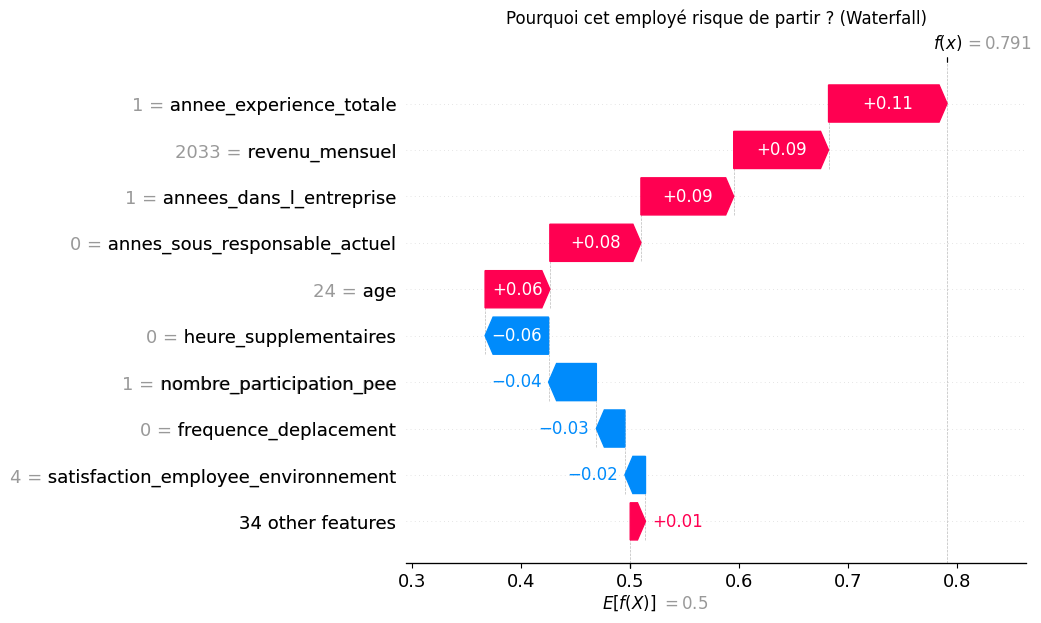

In [9]:
# --- C. Feature Importance Locale (Waterfall) ---
# Analyse "chirurgicale" d'un cas précis

# 1. On identifie les employés que le modèle pense voir partir (Proba > 0.35)
# On réutilise 'best_rf' et 'X_test' définis précédemment
y_probs_test = best_rf.predict_proba(X_test)[:, 1]
indices_a_risque = np.where(y_probs_test > 0.35)[0]

if len(indices_a_risque) > 0:
    # On prend le premier profil trouvé pour l'exemple
    idx_to_explain = indices_a_risque[0]
    
    print(f"--- Analyse Locale pour l'employé (Index Test : {idx_to_explain}) ---")
    print(f"Probabilité de départ prédite : {y_probs_test[idx_to_explain]:.2%}")
    
    # 2. Création de l'objet "Explanation" complet (Nécessaire pour le Waterfall)
    # Contrairement à shap_values, ceci contient aussi les données brutes pour l'affichage
    explanation = explainer(X_test)
    
    # 3. Affichage du Waterfall Plot
    # On doit sélectionner : [L'employé, Toutes les features, La classe 1 (Départ)]
    # La syntaxe [idx, :, 1] est spécifique aux modèles de classification binaire
    plt.title(f"Pourquoi cet employé risque de partir ? (Waterfall)")
    
    # Le try/except gère les différences de version de SHAP (Cube 3D vs Liste)
    try:
        # Syntaxe moderne pour Array 3D
        shap.plots.waterfall(explanation[idx_to_explain, :, 1])
    except Exception:
        # Fallback pour versions plus anciennes ou structures différentes
        # On essaie d'accéder sans la dimension de classe si elle est implicite
        shap.plots.waterfall(explanation[idx_to_explain])
        
else:
    print("Aucun employé détecté comme 'Partant' dans le jeu de test avec ce seuil.")